In [90]:
### we are import the nessseacrry libraries for scientififc computing and for plotting the data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,KFold

In [91]:
np.random.seed(0) # for reproducibility

In [92]:
dogs_whisker_length = np.random.normal(loc=5,scale=1,size = 10)
dogs_ear_flappiness_index = np.random.normal(loc=8,scale=1,size = 10)
cat_whisker_length = np.random.normal(loc=8,scale=1,size = 10)
cat_ear_flappiness_index = np.random.normal(loc=5,scale=1,size = 10)

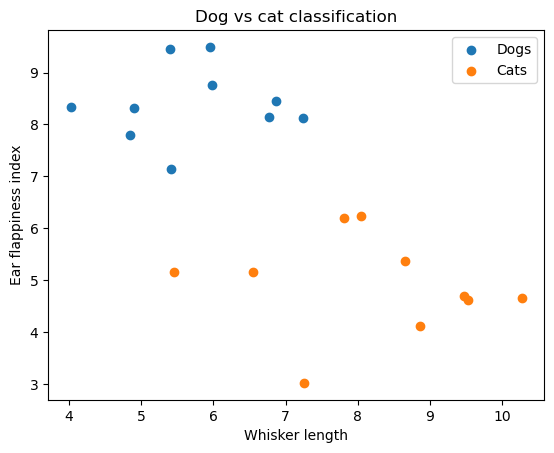

In [93]:
# plot data
plt.scatter(dogs_whisker_length,dogs_ear_flappiness_index,label = "Dogs")
plt.scatter(cat_whisker_length,cat_ear_flappiness_index ,label = "Cats")
plt.xlabel("Whisker length")
plt.ylabel("Ear flappiness index")
plt.title("Dog vs cat classification")
plt.legend() #legend is used to show the label of the data
plt.show()

In [94]:
def compute_error(data_dogs,data_cats,theta,theta0):
    error = 0
    for x_dog in data_dogs:
        if np.dot(theta,x_dog) + theta0 <= 0:
            error += 1
    for x_cats in data_cats:
        if np.dot(theta,x_cats) + theta0 > 0:
            error += 1

    return error


In [95]:
def random_linear_classifier(data_dogs,data_cats,k,d):
    # d is the number of features
    best_error = float('inf')# used to assign positive infinity
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        theta = np.random.normal(size= d)
        theta0 = np.random.normal()

        error = compute_error(data_dogs,data_cats,theta,theta0)

        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta,best_theta0


In [96]:
# .T is for transpose for converting (2,n) -> (n,2)

dogs_data = np.vstack((dogs_whisker_length,dogs_ear_flappiness_index)).T
cats_data = np.vstack((cat_whisker_length,cat_ear_flappiness_index)).T
data = np.vstack((dogs_data,cats_data))
labels = np.hstack((np.zeros(len(dogs_data)),np.ones(len(cats_data))))

In [97]:
x_train,x_test,y_train,y_test = train_test_split(data,labels,test_size=0.2,random_state=42)

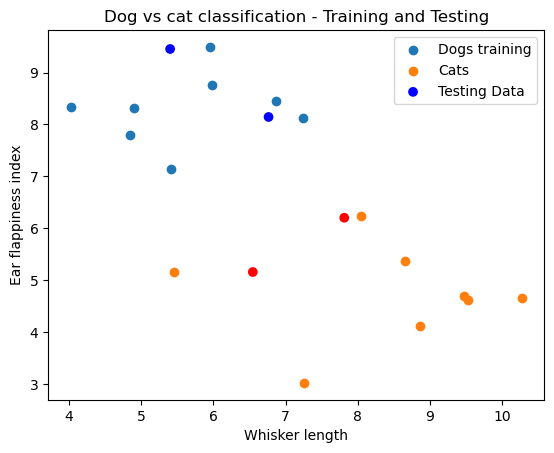

In [98]:
# plot training and testing data
# first training
plt.scatter(x_train[y_train==0][:,0],x_train[y_train==0][:,1],label = "Dogs training")
plt.scatter(x_train[y_train==1][:,0],x_train[y_train==1][:,1],label = "Cats")
# c represent colour based on class of y_test that is 0 and 1 here cmap = colour map 
#and bwr represent blue white red so class 0 is while class 1 is red and middle/neutral is white
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,cmap='bwr',label = 'Testing Data')
plt.xlabel("Whisker length")
plt.ylabel("Ear flappiness index")
plt.title("Dog vs cat classification - Training and Testing")
plt.legend() #legend is used to show the label of the data
plt.show()

In [99]:
# K fold error for k-fold Cross validation

def cross_validation(dogs_data,cats_data,k_values,d,n_split = 5):
    kf = KFold(n_splits=n_split,shuffle=True,random_state=42)
    avg_error = []

    for k in k_values:
        error = []
        for train_index ,val_index in kf.split(dogs_data):
            #  KFold.split() takes a single dataset and generates indices
            #  for splitting it into training and validation sets.
            x_train_fold = np.vstack((dogs_data[train_index],cats_data[train_index]))
            y_train_fold = np.hstack((np.zeros(len(train_index)),np.ones(len(train_index))))
            x_val_fold = np.vstack((dogs_data[val_index],cats_data[val_index]))
            y_val_fold = np.hstack((np.zeros(len(val_index)),np.ones(len(val_index))))

            best_theta_fold,best_theata0_fold = random_linear_classifier(x_train_fold[y_train_fold==0],x_train_fold[y_train_fold==1],k,d)

            error.append(compute_error(x_val_fold[y_val_fold==0],x_val_fold[y_val_fold==1],best_theta_fold,best_theata0_fold))

        avg_error.append(np.mean(error))

    best_k = k_values[np.argmin(avg_error)]   #np.argmin returns the index with minnimu value
    return best_k
            


In [100]:
# Run the randon linear classifier
k_values = [50,100,120,150,200,250,300,350,400]
d = 2
k = cross_validation(dogs_data,cats_data,k_values,d,5)
best_theta,best_theata0 = random_linear_classifier(x_train[y_train==0],x_train[y_train == 1],k,d)
print(k)

120


In [101]:
x_vals = np.linspace(2,10,100)
y_vals = (-best_theta[0]/best_theta[1])*x_vals -  (best_theata0/best_theta[1])


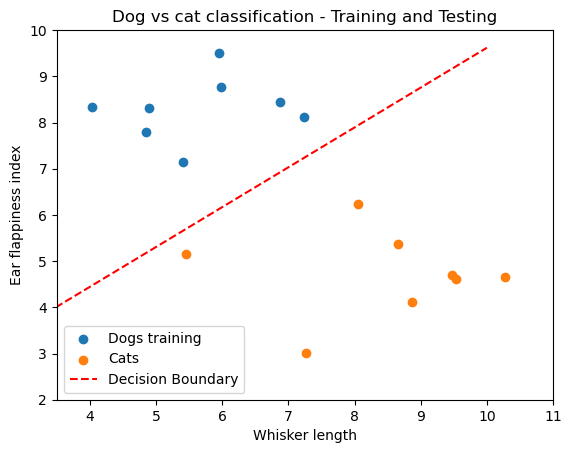

In [102]:
# plot training and testing data
# first training
plt.scatter(x_train[y_train==0][:,0],x_train[y_train==0][:,1],label = "Dogs training")
plt.scatter(x_train[y_train==1][:,0],x_train[y_train==1][:,1],label = "Cats")
# c represent colour based on class of y_test that is 0 and 1 here cmap = colour map 
#and bwr represent blue white red so class 0 is while class 1 is red and middle/neutral is white
plt.plot(x_vals,y_vals,color = 'red',linestyle='--',label ='Decision Boundary')
plt.xlabel("Whisker length")
plt.ylabel("Ear flappiness index")
plt.xlim(3.5,11)
plt.ylim(2,10)
plt.title("Dog vs cat classification - Training and Testing")
plt.legend() #legend is used to show the label of the data
plt.show()

In [103]:
train_error = compute_error(x_train[y_train == 0],x_train[y_train == 1],best_theta,best_theata0)

In [104]:
print(f"Training Error: {train_error}")

Training Error: 0


In [105]:
test_error = compute_error(x_test[y_test == 0],x_test[y_test == 1],best_theta,best_theata0)

In [106]:
print(f"Testing Error: {test_error}")

Testing Error: 0


In [107]:
x_vals_test = np.linspace(2,10,100)
y_vals_test = (-best_theta[0]/best_theta[1])*x_vals_test -  (best_theata0/best_theta[1])

x_test shape: (4, 2)
y_test shape: (4,)


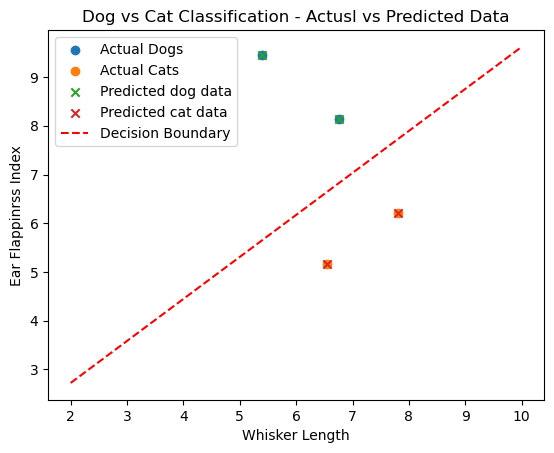

In [108]:
# Plot the actual Test Data
plt.scatter(x_test[y_test==0][:,0],x_test[y_test==0][:,1],label = "Actual Dogs")
plt.scatter(x_test[y_test==1][:,0],x_test[y_test==1][:,1],label = "Actual Cats")
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# Predict test data points using the decion boundary
predicted_labels = np.zeros_like(y_test)
for i,x in enumerate(x_test):
    if np.dot(best_theta,x) + best_theata0 < 0:
        predicted_labels[i] = 1

# plot the predicted data points
plt.scatter(x_test[predicted_labels == 0][:,0],x_test[predicted_labels == 0][:,1],marker='x',label = 'Predicted dog data')
plt.scatter(x_test[predicted_labels == 1][:,0],x_test[predicted_labels == 1][:,1],marker='x',label = 'Predicted cat data')

# Plot decsion Boundary
plt.plot(x_vals_test,y_vals_test,color = 'red',linestyle='--',label ='Decision Boundary')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappinrss Index')
plt.title("Dog vs Cat Classification - Actusl vs Predicted Data")
plt.legend()
plt.show()

Cross validation Error